In [43]:
#!pip install fastf1

# F1 Tyre Degradation & Lap Time Sensitivity Analysis
**Race: 2024 Bahrain Grand Prix**

The 2024 Bahrain GP was a two-stop race run exclusively on Soft and Hard compounds, no Medium was used. This makes it a clean case study for comparing two compounds with very different degradation profiles.

Using the FastF1 library, I pull real F1 timing and weather data to analyse how lap time evolves with tyre age, what environmental factors influence pace, and how degradation rates vary across drivers.

In [44]:
import fastf1
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score

## 1. Data Loading

I load the race session using FastF1 with weather data enabled. Telemetry is excluded, it's not needed here and significantly slows down the load.

In [45]:
session = fastf1.get_session(2024, 1, 'R')
session.load(telemetry=False, weather=True)

laps_df = session.laps
weather = session.weather_data

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.3]
INFO:fastf1.fastf1.core:Loading data for Bahrain Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
INFO:fastf1.fastf1.req:Using cached data for session_info
req            INFO 	Using cached data for driver_info
INFO:fastf1.fastf1.req:Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
INFO:fastf1.fastf1.req:Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
INFO:fastf1.fastf1.req:Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
INFO:fastf1.fastf1.req:Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
INFO:fastf1.fastf1.req:Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
INFO:fastf1.fastf1.req:Using cached data for timing_app_data
core         

## 2. Data Cleaning

Not all laps are usable for performance analysis. FastF1's `IsAccurate` flag handles most of the heavy lifting, it marks laps as reliable by accounting for yellow flags, pit entry/exit, safety cars, and sensor issues.

On top of that, I remove per-driver per-stint outliers beyond mean ± 2 standard deviations. This catches the occasional lap with a lock-up, traffic, or off that `IsAccurate` doesn't filter out.

Lap time is then converted from timedelta to seconds for numerical work.

In [46]:
laps_accurate = laps_df[laps_df['IsAccurate']].copy()
laps_accurate['lap_time_sec'] = laps_accurate.LapTime.dt.total_seconds()

std = laps_accurate[['DriverNumber', 'Stint', 'lap_time_sec']].groupby(['DriverNumber', 'Stint'], as_index=False).std()
std = std.rename(columns={'lap_time_sec': 'std'})
mean = laps_accurate[['DriverNumber', 'Stint', 'lap_time_sec']].groupby(['DriverNumber', 'Stint'], as_index=False).mean()
mean = mean.rename(columns={'lap_time_sec': 'mean'})

threshold_lap = std.merge(mean, on=['DriverNumber', 'Stint'])
threshold_lap['threshold'] = threshold_lap['mean'] + 2 * threshold_lap['std']

laps_accurate = laps_accurate.merge(threshold_lap[['DriverNumber', 'Stint', 'threshold']], on=['DriverNumber', 'Stint'])
laps_accurate = laps_accurate[laps_accurate['lap_time_sec'] <= laps_accurate['threshold']]

## 3. Compound Distribution

Before looking at degradation, it's worth understanding the basic pace characteristics of each compound. The Soft should be faster on median but less consistent, it's more sensitive to temperature, wear, and driver inputs than the Hard.

In [47]:
laps_accurate[['Compound', 'lap_time_sec']].groupby(['Compound'], as_index=False).aggregate(['std', 'mean'])

Compound lap_time_sec           
                    std       mean
0     HARD     1.048831  96.729893
1     SOFT     1.563114  97.321062

<Axes: xlabel='lap_time_sec', ylabel='Compound'>

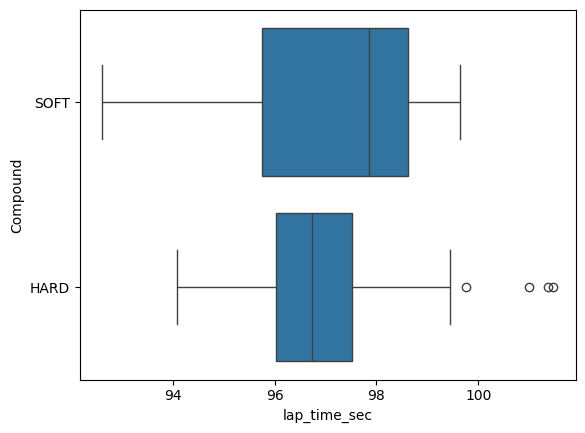

In [48]:
sns.boxplot(data=laps_accurate, x='lap_time_sec', y='Compound')

<Axes: xlabel='lap_time_sec', ylabel='Compound'>

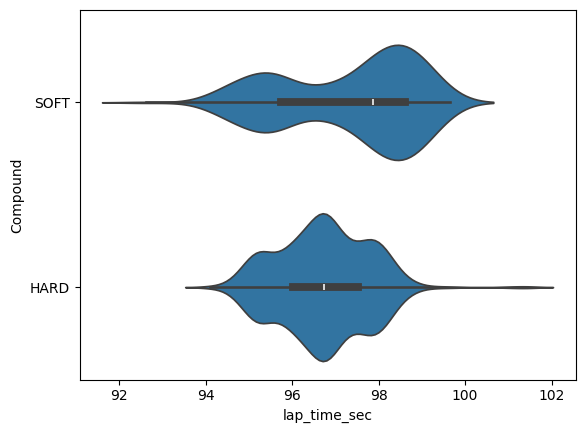

In [49]:
sns.violinplot(data=laps_accurate, x='lap_time_sec', y='Compound')

## 4. Lap Time vs Tyre Age

The obvious starting point, does lap time increase with tyre age? Each point is one lap, with a rolling median trend on top.

The short answer at this stage is: not clearly. Two effects are working against the degradation signal in this pooled view:
- **Fuel burn** — cars get lighter over the race, naturally improving lap times by around 0.03s/lap
- **Track evolution** — rubber laid down over 57 laps progressively increases grip

Both effects pull lap times down while degradation pushes them up. Section 7 deals with this properly by normalising within each stint.

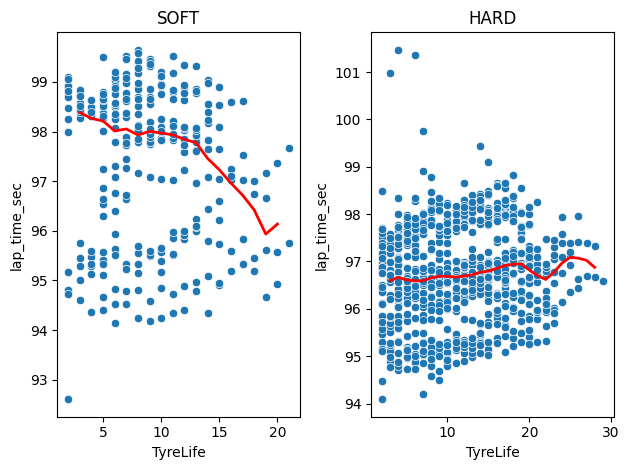

In [58]:
fig, axes = plt.subplots(1, 2)
for ax, compound in zip(axes, laps_accurate['Compound'].unique()):
  subset = laps_accurate[laps_accurate['Compound'] == compound]
  trend = subset.groupby('TyreLife', as_index=False)['lap_time_sec'].median().rolling(3, center=True).mean()
  sns.scatterplot(data=subset, y='lap_time_sec', x='TyreLife', ax=ax)
  ax.plot(trend.TyreLife, trend.lap_time_sec, color='red', linewidth=2)
  ax.set_title(compound)
fig.tight_layout()

## 5. Sensitivity Analysis

I compute the Pearson correlation between lap time and a set of variables, tyre age, lap number, air temperature, track temperature, humidity, and wind speed.

The result is essentially a sensitivity matrix: which factors move lap time, and in which direction? Positive correlation means the variable makes cars slower, negative means faster. This kind of analysis is directly relevant to regulatory work — if you're changing a rule that affects operating temperatures, you want to know how sensitive lap time is to those conditions before and after.

In [51]:
weather_lap_df = pd.merge_asof(laps_accurate[["Time", "lap_time_sec", "Compound", "TyreLife"]].sort_values("Time"), weather, left_on="Time", right_on="Time", direction="nearest", tolerance=pd.Timedelta("1m"))
weather_lap_df = weather_lap_df.drop(columns=["Time", "Pressure", "Rainfall", "WindDirection"])

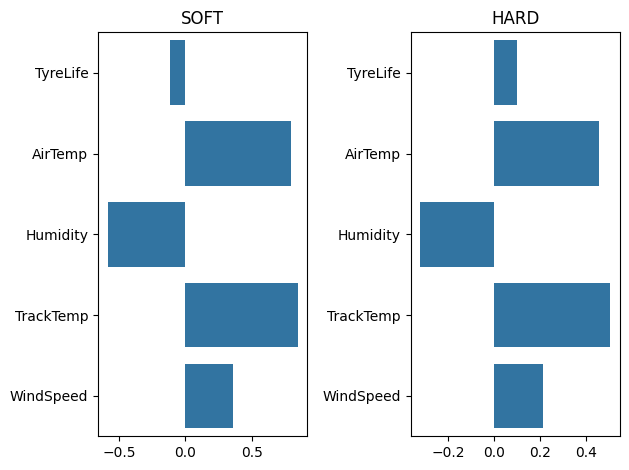

In [59]:
fig, axes = plt.subplots(1, 2)
for axe, compound in zip(axes, weather_lap_df['Compound'].unique()):
  subset = weather_lap_df[weather_lap_df['Compound'] == compound]
  subset = subset.drop(columns=['Compound'])
  corr_df = subset.drop(columns=['lap_time_sec']).corrwith(subset['lap_time_sec'])
  sns.barplot(x=corr_df.values, y=corr_df.index, ax=axe)
  axe.set_ylabel("")
  axe.set_title(compound)

fig.tight_layout()

## 6. Degradation Model Fitting

Here I fit a linear and a second-degree polynomial to the lap time vs tyre age data for each compound.

The slope of the linear model is the degradation rate in seconds per lap, the single most useful number for strategy work. The polynomial captures whether degradation accelerates at high tyre age, which is physically realistic as the tyre surface wears through.

R² values are low across the board, which is expected when pooling all drivers. Absolute pace differences between drivers swamp the degradation signal. The rates are still meaningful, the normalised analysis in section 7 will confirm them more cleanly.

Note: the median line on the Soft becomes less reliable beyond lap 15, very few drivers ran a Soft stint that long, so the median is based on a handful of observations rather than the full field. This is expected: the Soft compound degrades quickly enough that most drivers pitted well before lap 20.

======= SOFT ======
=== Polynomial degree: 1 ===
Degradation rate: -0.04229168925707368
R2=0.014145532070711453
=== Polynomial degree: 2 ===
Degradation rate: 0.17925428931919568
R2=0.040203333795208795
======= HARD ======
=== Polynomial degree: 1 ===
Degradation rate: 0.016495894131049002
R2=0.009565028735063485
=== Polynomial degree: 2 ===
Degradation rate: 0.05097392588997613
R2=0.01251934792975562


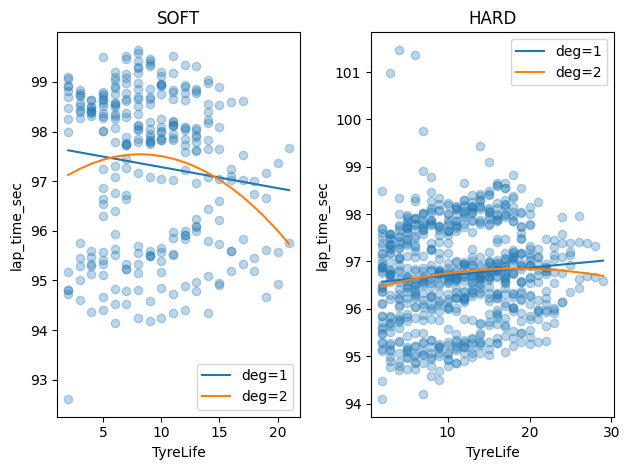

In [60]:
degradation_model_df = laps_accurate[['Compound', 'TyreLife', 'lap_time_sec']]

fig, axes = plt.subplots(1,2)
for ax, compound in zip(axes, degradation_model_df.Compound.unique()):
  print('======= {} ======'.format(compound))
  subset = degradation_model_df[degradation_model_df['Compound'] == compound]
  x = subset.TyreLife
  y = subset.lap_time_sec
  ax.scatter(x, y, alpha=0.3)
  x_plot = np.arange(x.min(), x.max() + 1)
  for i in range(2):
    print("=== Polynomial degree: {} ===".format(i+1))
    coefs = np.polyfit(x, y, deg=i+1)
    print("Degradation rate:", coefs[-2])
    y_pred = np.polyval(coefs, x)
    r2 = r2_score(y, y_pred)
    print("R2={}".format(r2))
    ax.plot(x_plot, np.polyval(coefs, x_plot), label=f'deg={i+1}')
    ax.set_xlabel('TyreLife')
    ax.set_ylabel('lap_time_sec')

    ax.set_title(compound)
    ax.legend()

  fig.tight_layout()


## 7. Normalised Stint Analysis

To get a cleaner degradation signal I normalise each stint: subtract the first lap time so every stint starts at zero. The y-axis then shows time lost relative to each driver's own baseline, which removes between-driver pace differences.

It doesn't fully remove the fuel load effect though, fuel burn improves lap time by roughly 0.03s/lap within a stint, which partially offsets the measured degradation. The true tyre degradation is slightly steeper than the fitted slopes suggest.

With that caveat noted, the normalised view is considerably more revealing than the raw data.

In [54]:
normalised_stint_df = laps_accurate[['Driver', 'Stint', 'TyreLife', 'lap_time_sec', 'Compound']]

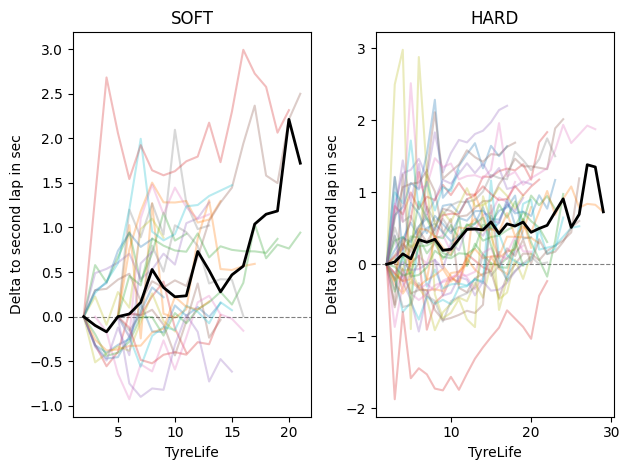

In [63]:
fig, axes = plt.subplots(1, 2)
for ax, compound in zip(axes, normalised_stint_df['Compound'].unique()):
  subset = normalised_stint_df[normalised_stint_df['Compound'] == compound]


  ax.set_title(compound)
  ax.axhline(0, color='grey', linestyle='--', linewidth=0.8)

  all_deltas = []
  for (driver, stint), group in subset.groupby(['Driver', "Stint"]):
    group = group.sort_values("TyreLife")
    group['delta'] = group['lap_time_sec'] - group['lap_time_sec'].iloc[0]
    all_deltas.append(group[['TyreLife', 'delta']])
    ax.plot(group['TyreLife'].values, group['delta'].values, alpha=0.3)
    ax.set_xlabel("TyreLife")
    ax.set_ylabel("Delta to second lap in sec")

  delta_df = pd.concat(all_deltas)
  median_delta = delta_df.groupby('TyreLife')['delta'].median()
  ax.plot(median_delta.index, median_delta.values, color='black', linewidth=2, label='Median')
  fig.tight_layout()



## 8. Driver Degradation Rate Comparison

I fit a linear model to each driver's normalised stint to extract a degradation rate in seconds per lap, then average across stints where a driver used the same compound more than once.

A lower rate means better tyre management, the driver is sustaining pace further into the stint. Negative values are worth interpreting carefully: they don't necessarily mean the tyre is getting faster with age. As noted in section 7, fuel burn contributes roughly -0.03s/lap improvement within a stint. On the Hard compound where tyre degradation is minimal, this fuel effect can dominate and produce a net negative slope. A driver showing -0.02s/lap on the Hard is likely just reflecting fuel burn rather than genuine tyre improvement.

In [56]:
stint_rates = []
for (driver, stint), group in normalised_stint_df.groupby(['Driver', "Stint"]):
  if len(group) < 4:
    continue
  group = group.sort_values("TyreLife")
  group['delta'] = group['lap_time_sec'] - group['lap_time_sec'].iloc[0]
  coefs = np.polyfit(group['TyreLife'].values, group['delta'].values, deg=1)
  stint_rates.append({'Driver': driver, 'Compound': group['Compound'].iloc[0], 'DegRate': coefs[0]})

df_rates = pd.DataFrame(stint_rates)


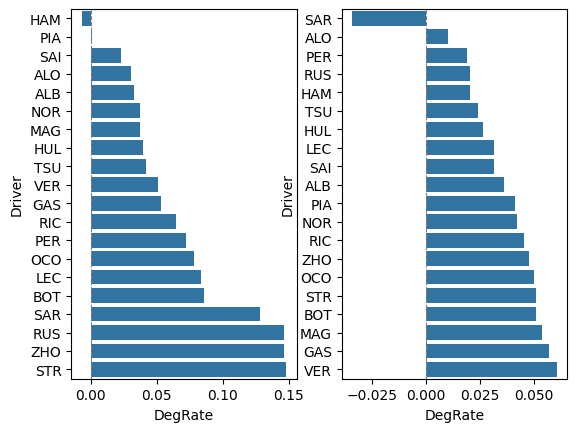

In [57]:
fig, axes = plt.subplots(1,2)
for ax, compound in zip(axes, df_rates['Compound'].unique()):
  subset = df_rates[df_rates['Compound'] == compound].groupby('Driver')['DegRate'].mean().reset_index().sort_values('DegRate')
  sns.barplot(y=subset['Driver'], x=subset['DegRate'], ax=ax)
  ax.axvline(0, color='grey', linestyle='--', linewidth=0.8)

## Summary

- Bahrain 2024 was a **Soft/Hard two-stop race** with no Medium used.
- **Soft tyres** degrade meaningfully, around +0.08s/lap in the normalised analysis, though this is partially offset by fuel burn and track evolution in the raw data.
- **Hard tyres** are far more durable, with near-flat median degradation and high inter-driver variance reflecting different stint lengths.
- **Track temperature** is the strongest environmental driver of lap time on both compounds, consistent with Bahrain's conditions.
- **Tyre age alone explains very little of raw lap time variance** (R² < 0.05). Driver differences and environmental factors dominate — normalising per stint is essential to see the degradation signal clearly.
- The spread in degradation rates across drivers points to **driving style** as a significant factor in tyre management, beyond car design alone.

**Known limitations**
- Fuel load is not fully corrected for, degradation rates are slightly underestimated
- Traffic and DRS availability are uncontrolled
- A single race is a limited sample, a multi-race version of this analysis would give more robust compound characterisation